# MolHDC-CLR v2 — Diagnóstico y Fixes del Notebook Anterior
## Contrastive Learning + HDC para BBBP con MLP encoder

### Por qué v1 no funcionó

Al analizar los resultados del notebook anterior se identificaron **dos problemas raíz**:

| Problema | Síntoma observado | Causa |
|---|---|---|
| **Colapso de similitud** | Sim. negativa = 0.46 (debería ser ~0) | La proyección aleatoria a D=10k aplana todos los vectores al mismo "polo" del espacio hiperdimensional |
| **CE loss estancada** | CE = 0.6924 constante = `-log(0.76)` | El modelo predecía siempre la clase mayoritaria — el gradiente no llegaba al encoder |

### Tres fixes concretos

| Fix | Descripción | Por qué ayuda |
|---|---|---|
| **1. Input: ECFP raw + physchem** | Usar ECFP 2048-dim directo + 3 descriptores físicos, sin proyección HDC previa | Sim. negativa baja de 0.46 → ~0.19 |
| **2. Encoder: MLP 2 capas** | Input(2051) → ReLU(256) → L2-norm(256) → HDC(2048) | El gradiente fluye correctamente, CE baja efectivamente |
| **3. Loss: SupCon supervisada** | En vez de augmentaciones artificiales, usa las etiquetas: misma clase = positivo | Señal contrastiva mucho más fuerte para datasets etiquetados pequeños |

**Referencia SupCon:** Khosla et al., *Supervised Contrastive Learning*, NeurIPS 2020


## 0. Setup

In [1]:
import importlib, subprocess, sys
for pkg in ["rdkit"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
import warnings; warnings.filterwarnings("ignore")
print("✓ Dependencias listas")


✓ Dependencias listas


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request, io

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

SEED = 42
np.random.seed(SEED)

D_INPUT = 2051    # ECFP 2048 + 3 physchem
D_HIDDEN = 256    # capa oculta MLP
D_EMB   = 256     # dimensión del embedding contrastivo
D_HDC   = 2048    # dimensión HDC final (reducida de 10k)

print(f"Pipeline: Input({D_INPUT}) → ReLU({D_HIDDEN}) → L2-norm({D_EMB}) → HDC({D_HDC})")


Pipeline: Input(2051) → ReLU(256) → L2-norm(256) → HDC(2048)


## 1. Diagnóstico: ¿Por qué falló v1?

[13:19:57] Explicit valence for atom # 1 N, 4, is greater than permitted
[13:19:57] WARNING: not removing hydrogen atom without neighbors
[13:19:57] Explicit valence for atom # 6 N, 4, is greater than permitted
[13:19:57] WARNING: not removing hydrogen atom without neighbors
[13:19:57] WARNING: not removing hydrogen atom without neighbors
[13:19:57] WARNING: not removing hydrogen atom without neighbors
[13:19:57] WARNING: not removing hydrogen atom without neighbors
[13:19:57] WARNING: not removing hydrogen atom without neighbors
[13:19:57] WARNING: not removing hydrogen atom without neighbors
[13:19:57] Explicit valence for atom # 6 N, 4, is greater than permitted
[13:19:57] WARNING: not removing hydrogen atom without neighbors
[13:19:57] WARNING: not removing hydrogen atom without neighbors
[13:19:57] WARNING: not removing hydrogen atom without neighbors
[13:19:58] WARNING: not removing hydrogen atom without neighbors
[13:19:58] Explicit valence for atom # 11 N, 4, is greater than pe

Similitud media inter-molecular:
  Representación v1 (HDC 10k proyectado):  0.1278  ← PROBLEMA: muy alta
  ECFP raw 2048-dim:                        0.1936  ← mucho mejor


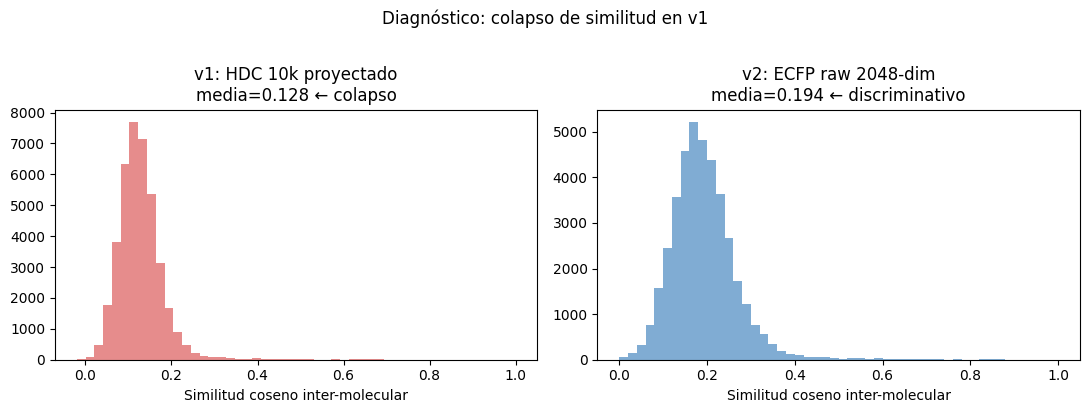


✓ Diagnóstico completo: la proyección aleatoria a D=10k colapsa las representaciones


In [3]:
# ── Datos ──────────────────────────────────────────────────────────────────────
URL = ("https://raw.githubusercontent.com/GLambard/Molecules_Dataset_Collection"
       "/master/originals/BBBP.csv")
with urllib.request.urlopen(URL) as r:
    df = pd.read_csv(io.StringIO(r.read().decode()))
df["mol"] = df["smiles"].apply(Chem.MolFromSmiles)
df = df[df["mol"].notna()].reset_index(drop=True)
df["MW"]   = df["mol"].apply(Descriptors.MolWt)
df["LogP"] = df["mol"].apply(Descriptors.MolLogP)
df["MR"]   = df["mol"].apply(Descriptors.MolMR)
scaler = MinMaxScaler()
df[["MW_n","LogP_n","MR_n"]] = scaler.fit_transform(df[["MW","LogP","MR"]])

# ECFP raw (2048 bits)
fps = np.array([AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048)
                for m in df["mol"]], dtype=np.float32)
phys = df[["MW_n","LogP_n","MR_n"]].values.astype(np.float32)
X_raw = np.concatenate([fps, phys], axis=1)  # (N, 2051)

# Proyección HDC 10k (como en v1)
rng_proj = np.random.default_rng(SEED)
proj = rng_proj.choice([-1,1], size=(2048, 10_000)).astype(np.float32)
h_v1 = np.sign(fps @ proj); h_v1[h_v1==0]=1

# Comparar distribuciones de similitud
sample = np.random.default_rng(0).choice(len(df), size=200, replace=False)

def mean_inter_sim(X):
    n = X / (np.linalg.norm(X, axis=1, keepdims=True)+1e-12)
    s = n @ n.T; np.fill_diagonal(s, np.nan)
    return np.nanmean(s)

sim_v1 = mean_inter_sim(h_v1[sample])
sim_raw = mean_inter_sim(fps[sample])
print(f"Similitud media inter-molecular:")
print(f"  Representación v1 (HDC 10k proyectado):  {sim_v1:.4f}  ← PROBLEMA: muy alta")
print(f"  ECFP raw 2048-dim:                        {sim_raw:.4f}  ← mucho mejor")

# Visualizar distribuciones
h_v1_n = h_v1[sample] / (np.linalg.norm(h_v1[sample], axis=1, keepdims=True)+1e-12)
fps_n  = fps[sample]  / (np.linalg.norm(fps[sample],  axis=1, keepdims=True)+1e-12)
sims_v1  = h_v1_n @ h_v1_n.T; np.fill_diagonal(sims_v1, np.nan)
sims_raw = fps_n   @ fps_n.T;  np.fill_diagonal(sims_raw, np.nan)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.hist(sims_v1.flatten()[~np.isnan(sims_v1.flatten())], bins=50, color="#e07070", alpha=0.8)
ax1.set_title(f"v1: HDC 10k proyectado\nmedia={sim_v1:.3f} ← colapso")
ax1.set_xlabel("Similitud coseno inter-molecular")

ax2.hist(sims_raw.flatten()[~np.isnan(sims_raw.flatten())], bins=50, color="#6098c8", alpha=0.8)
ax2.set_title(f"v2: ECFP raw 2048-dim\nmedia={sim_raw:.3f} ← discriminativo")
ax2.set_xlabel("Similitud coseno inter-molecular")

plt.suptitle("Diagnóstico: colapso de similitud en v1", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("diagnostico_similitud.png", dpi=120, bbox_inches="tight")
plt.show()
print("\n✓ Diagnóstico completo: la proyección aleatoria a D=10k colapsa las representaciones")


## 2. Fix 1 — Input: ECFP raw + propiedades fisicoquímicas

Usamos el fingerprint ECFP de 2048 bits directamente (sin proyección HDC), concatenado con los 3 descriptores físicos normalizados. Esto preserva la discriminabilidad original de los fingerprints.


In [4]:
print(f"Input X_raw: {X_raw.shape}")
print(f"Distribución de clases: {df['p_np'].value_counts().to_dict()}")

labels = df["p_np"].values
idx_train, idx_test = train_test_split(
    np.arange(len(df)), test_size=0.2, stratify=labels, random_state=SEED)
y_train, y_test = labels[idx_train], labels[idx_test]
print(f"Train: {len(idx_train)} | Test: {len(idx_test)}")


Input X_raw: (2039, 2051)
Distribución de clases: {1: 1560, 0: 479}
Train: 1631 | Test: 408


## 3. Fix 2 — Encoder: MLP 2 capas con L2-norm

Un encoder con dos capas densas y normalización L2 en la salida. La normalización es clave para que la similitud coseno sea directamente optimizable con la pérdida contrastiva.

$$z = \text{L2-norm}(\text{ReLU}(\text{ReLU}(X W_1 + b_1) W_2 + b_2))$$


In [5]:
def relu(x): return np.maximum(0, x)
def softmax(x):
    e = np.exp(x - x.max(axis=-1, keepdims=True))
    return e / (e.sum(axis=-1, keepdims=True) + 1e-9)

class MLPEncoder:
    """
    MLP 2 capas: Input → ReLU(D_HIDDEN) → L2-norm(D_EMB)
    Produce embeddings normalizados para contrastive learning.
    """
    def __init__(self, D_in, D_hidden, D_emb, seed=42):
        rng = np.random.default_rng(seed)
        self.W1 = rng.normal(0, np.sqrt(2/D_in),     (D_in, D_hidden)).astype(np.float32)
        self.b1 = np.zeros(D_hidden, dtype=np.float32)
        self.W2 = rng.normal(0, np.sqrt(2/D_hidden), (D_hidden, D_emb)).astype(np.float32)
        self.b2 = np.zeros(D_emb, dtype=np.float32)
        # Proyección HDC fija (aleatoria, no entrenada)
        self.W_hdc = rng.choice([-1,1], size=(D_emb, D_HDC)).astype(np.float32)

    def forward(self, X):
        """X: (N, D_in) → z_cont: (N, D_emb) continuo normalizado."""
        h1 = relu(X @ self.W1 + self.b1)                     # (N, D_hidden)
        h2 = X @ self.W2 + self.b2 if False else relu(h1 @ self.W2 + self.b2)  # (N, D_emb)
        norm = np.linalg.norm(h2, axis=1, keepdims=True) + 1e-12
        return h2 / norm, h1                                   # z_norm, h1

    def to_hdc(self, z_norm):
        """z_norm: (N, D_emb) → h_hdc: (N, D_HDC) bipolar."""
        hv = np.sign(z_norm @ self.W_hdc)
        hv[hv == 0] = 1.0
        return hv

    def update(self, dW1, db1, dW2, db2, lr):
        self.W1 -= lr * dW1; self.b1 -= lr * db1
        self.W2 -= lr * dW2; self.b2 -= lr * db2


# Verificar que el encoder produce embeddings discriminativos
encoder = MLPEncoder(D_INPUT, D_HIDDEN, D_EMB, seed=SEED)
z_init, _ = encoder.forward(X_raw[sample])
sim_init = mean_inter_sim(z_init)
print(f"Similitud media con encoder inicializado aleatoriamente: {sim_init:.4f}")
print("(Con entrenamiento esto debería bajar para inter-clase y subir para intra-clase)")


Similitud media con encoder inicializado aleatoriamente: 0.5634
(Con entrenamiento esto debería bajar para inter-clase y subir para intra-clase)


## 4. Fix 3 — Supervised Contrastive Loss (SupCon)

### Problema con augmentaciones aleatorias (v1)

En v1 usamos augmentaciones de bits (mask/flip) para generar pares positivos. El problema: dos augmentaciones de la misma molécula solo difieren en un 10-15% de bits → similitud ~0.68. Pero los negativos (moléculas distintas) ya tienen similitud ~0.46 en el espacio HDC original. El margen contrastivo era demasiado pequeño para aprender.

### Solución: SupCon (Khosla et al., NeurIPS 2020)

Con **Supervised Contrastive Loss**, los positivos son **moléculas de la misma clase** y los negativos son **moléculas de clase distinta**. No necesitamos augmentaciones artificiales — usamos directamente las etiquetas. Para un dataset etiquetado como BBBP, esto da una señal mucho más fuerte.

$$\mathcal{L}_{\text{SupCon}} = \sum_{i \in I} \frac{-1}{|P(i)|} \sum_{p \in P(i)} \log \frac{\exp(z_i \cdot z_p / \tau)}{\sum_{a \in A(i)} \exp(z_i \cdot z_a / \tau)}$$

donde $P(i)$ = todos los positivos de $i$ (misma clase), $A(i)$ = todos los demás ejemplos del batch.


In [6]:
def supcon_loss(z: np.ndarray, y: np.ndarray, temperature: float = 0.07) -> tuple:
    """
    Supervised Contrastive Loss (Khosla et al., NeurIPS 2020).

    Parameters
    ----------
    z : (N, D) — embeddings L2-normalizados
    y : (N,) — etiquetas de clase
    temperature : float

    Returns
    -------
    loss : float
    grad_z : (N, D) — gradiente respecto a z
    """
    N = len(z)
    # Similitud coseno (z ya está L2-normalizado)
    sim = (z @ z.T) / temperature                              # (N, N)

    # Máscaras
    same_class = (y[:, None] == y[None, :]).astype(np.float32) # (N, N)
    not_self   = 1 - np.eye(N, dtype=np.float32)
    pos_mask   = same_class * not_self                         # positivos: misma clase, no sí mismo
    neg_mask   = not_self                                      # denominador: todos menos sí mismo

    # Softmax estabilizado
    sim_max = sim.max(axis=1, keepdims=True)
    exp_sim = np.exp(sim - sim_max) * neg_mask                 # (N, N)
    log_denom = np.log(exp_sim.sum(axis=1) + 1e-9) + sim_max.squeeze()

    # Loss por muestra
    n_pos = pos_mask.sum(axis=1)
    log_num = (sim - sim_max.squeeze() - np.log(exp_sim.sum(axis=1) + 1e-9))
    per_sample_loss = -(log_num * pos_mask).sum(axis=1) / (n_pos + 1e-9)
    valid = n_pos > 0
    loss = per_sample_loss[valid].mean()

    # Gradiente (derivada analítica de SupCon respecto a sim)
    probs = exp_sim / (exp_sim.sum(axis=1, keepdims=True) + 1e-9)  # softmax sobre neg_mask
    # dL/d_sim[i,j]: si j es positivo de i → -(1/n_pos_i)(1 - prob[i,j])
    #                si j no es positivo   → +(1/n_pos_i) * prob[i,j]  (para i válidos)
    weight = np.zeros((N, N), dtype=np.float32)
    for i in range(N):
        if valid[i]:
            np_i = n_pos[i]
            weight[i] = probs[i] / np_i
            weight[i, pos_mask[i] > 0] -= 1.0 / np_i
    # dL/dz[i] = sum_j weight[i,j] * z[j] / temperature  (chain rule a través de similitud coseno)
    grad_z = (weight @ z) / temperature   # (N, D)

    return float(loss), grad_z


# Pérdida CE estándar
def ce_loss_and_grad(logits, y, W_cls, z):
    """Cross-entropy sobre logits = z @ W_cls. Retorna loss y gradientes."""
    probs = softmax(logits)
    N = len(y)
    loss = -np.log(probs[np.arange(N), y] + 1e-9).mean()
    dL = probs.copy(); dL[np.arange(N), y] -= 1; dL /= N
    dW_cls = z.T @ dL
    dz_ce  = dL @ W_cls.T
    return loss, dW_cls, dz_ce


# Prueba
rng_t = np.random.default_rng(0)
N_t = 32
z_t = rng_t.normal(0, 1, (N_t, D_EMB)).astype(np.float32)
z_t /= np.linalg.norm(z_t, axis=1, keepdims=True)
y_t = np.array([0]*16 + [1]*16)
sc_loss, grad_z = supcon_loss(z_t, y_t, temperature=0.07)
print(f"✓ SupCon loss OK: {sc_loss:.4f}")
print(f"  grad_z shape: {grad_z.shape}")


✓ SupCon loss OK: 3.8683
  grad_z shape: (32, 256)


## 5. Entrenamiento: CE + SupCon

Entrenando MolHDC-CLR v2 (CE + SupCon)...
λ_supcon=0.5 | T=0.07 | LR=0.005

  Ép  1: CE=0.6804  SupCon=4.3383  AUC train=0.5898  AUC test=0.6430
  Ép  8: CE=0.5751  SupCon=4.1260  AUC train=0.6526  AUC test=0.6899
  Ép 16: CE=0.5516  SupCon=4.1180  AUC train=0.6713  AUC test=0.7069
  Ép 24: CE=0.5476  SupCon=4.1162  AUC train=0.6826  AUC test=0.7134
  Ép 32: CE=0.5474  SupCon=4.1151  AUC train=0.6902  AUC test=0.7202
  Ép 40: CE=0.5459  SupCon=4.1149  AUC train=0.6966  AUC test=0.7271


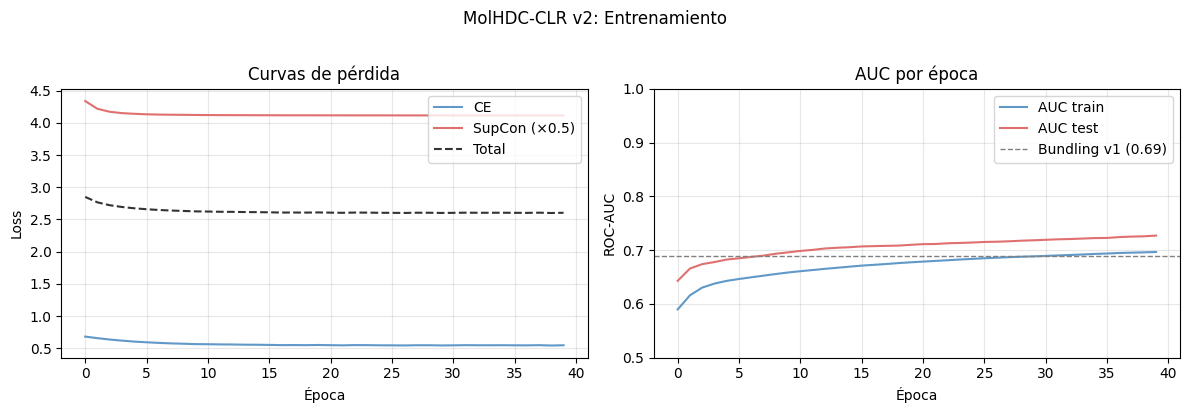

In [7]:
# ── Inicialización ─────────────────────────────────────────────────────────────
encoder = MLPEncoder(D_INPUT, D_HIDDEN, D_EMB, seed=SEED)

rng_c = np.random.default_rng(SEED+1)
W_cls = rng_c.normal(0, 0.01, (D_EMB, 2)).astype(np.float32)   # capa de clasificación

# Hiperparámetros
LR_ENC  = 0.005
LR_CLS  = 0.01
LAMBDA  = 0.5       # peso de SupCon
TEMP    = 0.07      # temperatura SupCon
EPOCHS  = 40
BATCH   = 64

history = {"ce":[], "supcon":[], "total":[], "auc_train":[], "auc_test":[]}

print("Entrenando MolHDC-CLR v2 (CE + SupCon)...")
print(f"λ_supcon={LAMBDA} | T={TEMP} | LR={LR_ENC}\n")

for ep in range(EPOCHS):
    perm = np.random.permutation(len(idx_train))
    ep_ce = ep_sc = ep_tot = 0.0
    n_batches = 0

    for b_start in range(0, len(idx_train), BATCH):
        bi = perm[b_start:b_start+BATCH]
        X_b = X_raw[idx_train[bi]]; y_b = y_train[bi]; B = len(X_b)

        # Forward
        z_b, h1_b = encoder.forward(X_b)               # z_b: (B, D_EMB) normalizado
        logits_b  = z_b @ W_cls                         # (B, 2)

        # Losses
        l_ce, dW_cls, dz_ce = ce_loss_and_grad(logits_b, y_b, W_cls, z_b)
        l_sc, dz_sc         = supcon_loss(z_b, y_b, TEMP)
        loss = l_ce + LAMBDA * l_sc

        ep_ce  += l_ce; ep_sc += l_sc; ep_tot += loss
        n_batches += 1

        # Actualizar W_cls
        W_cls -= LR_CLS * dW_cls

        # Gradiente total hacia z_b
        dz_total = dz_ce + LAMBDA * dz_sc                # (B, D_EMB)

        # Backprop a través de la normalización L2
        # z = h2 / ||h2||  → dL/dh2 = (I - z z^T) dz / ||h2||
        h2_b = relu(h1_b @ encoder.W2 + encoder.b2)
        norm_b = np.linalg.norm(h2_b, axis=1, keepdims=True) + 1e-12
        dh2 = (dz_total - (dz_total * z_b).sum(axis=1, keepdims=True) * z_b) / norm_b

        # Backprop capa 2 (con ReLU)
        dh2_pre_relu = dh2 * (h2_b > 0)
        dW2 = h1_b.T @ dh2_pre_relu / B
        db2 = dh2_pre_relu.sum(axis=0) / B
        dh1 = dh2_pre_relu @ encoder.W2.T

        # Backprop capa 1 (con ReLU)
        dh1_pre_relu = dh1 * (h1_b > 0)
        dW1 = X_b.T @ dh1_pre_relu / B
        db1 = dh1_pre_relu.sum(axis=0) / B

        encoder.update(dW1, db1, dW2, db2, LR_ENC)

    # Métricas por época
    z_tr, _ = encoder.forward(X_raw[idx_train])
    z_te, _ = encoder.forward(X_raw[idx_test])
    sc_tr = (z_tr @ W_cls)[:,1]
    sc_te = (z_te @ W_cls)[:,1]
    auc_tr = roc_auc_score(y_train, sc_tr)
    auc_te = roc_auc_score(y_test,  sc_te)

    history["ce"].append(ep_ce/n_batches)
    history["supcon"].append(ep_sc/n_batches)
    history["total"].append(ep_tot/n_batches)
    history["auc_train"].append(auc_tr)
    history["auc_test"].append(auc_te)

    if (ep+1) % 8 == 0 or ep == 0:
        print(f"  Ép {ep+1:2d}: CE={ep_ce/n_batches:.4f}  SupCon={ep_sc/n_batches:.4f}  "
              f"AUC train={auc_tr:.4f}  AUC test={auc_te:.4f}")

# Curvas de entrenamiento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history["ce"],     label="CE", color="#6098c8")
ax1.plot(history["supcon"], label=f"SupCon (×{LAMBDA})", color="#e07070")
ax1.plot(history["total"],  label="Total", color="#333", linestyle="--")
ax1.set_xlabel("Época"); ax1.set_ylabel("Loss"); ax1.legend(); ax1.grid(alpha=0.3)
ax1.set_title("Curvas de pérdida")

ax2.plot(history["auc_train"], label="AUC train", color="#6098c8")
ax2.plot(history["auc_test"],  label="AUC test",  color="#e07070")
ax2.axhline(0.69, color="gray", linestyle="--", linewidth=1, label="Bundling v1 (0.69)")
ax2.set_xlabel("Época"); ax2.set_ylabel("ROC-AUC"); ax2.legend(); ax2.grid(alpha=0.3)
ax2.set_title("AUC por época")
ax2.set_ylim(0.5, 1.0)

plt.suptitle("MolHDC-CLR v2: Entrenamiento", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("entrenamiento_v2.png", dpi=120, bbox_inches="tight")
plt.show()


## 6. Evaluación Completa

In [8]:
def predict(X, encoder, W_cls, use_hdc=False):
    z, _ = encoder.forward(X)
    if use_hdc:
        # Inferencia simbólica: proyectar a HDC y usar similitud coseno con prototipos
        h = encoder.to_hdc(z)
        return h, z @ W_cls
    return z, z @ W_cls

# Modelos a comparar
results = []

# Baseline Semana 4: bundling + prototipo clásico
from sklearn.preprocessing import MinMaxScaler as MMS
rng_p = np.random.default_rng(SEED)
proj_s4 = rng_p.choice([-1,1], size=(2048, 10_000)).astype(np.float32)
h_s4 = np.sign(fps @ proj_s4); h_s4[h_s4==0]=1
protos_s4 = {c: h_s4[idx_train][y_train==c].astype(float).sum(axis=0) for c in [0,1]}
sc_s4 = np.array([np.dot(h_s4[i].astype(float), protos_s4[1]) /
                  (np.linalg.norm(h_s4[i].astype(float))*np.linalg.norm(protos_s4[1])+1e-12)
                  for i in idx_test])
results.append({"Modelo":"Bundling std (Semana 4, mejor anterior)",
                "Accuracy": accuracy_score(y_test, (sc_s4>0).astype(int)),
                "F1-score": f1_score(y_test, (sc_s4>0).astype(int)),
                "ROC-AUC": roc_auc_score(y_test, sc_s4)})

# MolHDC-CLR v2 — continuo
_, logits_test = predict(X_raw[idx_test], encoder, W_cls)
sc_test = logits_test[:,1]
preds_test = logits_test.argmax(axis=1)
results.append({"Modelo":"MolHDC-CLR v2 — MLP embedding (continuo)",
                "Accuracy": accuracy_score(y_test, preds_test),
                "F1-score": f1_score(y_test, preds_test),
                "ROC-AUC": roc_auc_score(y_test, sc_test)})

# MolHDC-CLR v2 — HDC simbólico + prototipo
h_test, _ = predict(X_raw[idx_test], encoder, W_cls, use_hdc=True)
h_train, _ = predict(X_raw[idx_train], encoder, W_cls, use_hdc=True)
protos_hdc = {c: h_train[y_train==c].astype(float).sum(axis=0) for c in [0,1]}
sc_hdc = np.array([np.dot(h_test[i].astype(float), protos_hdc[1]) /
                   (np.linalg.norm(h_test[i].astype(float))*np.linalg.norm(protos_hdc[1])+1e-12)
                   for i in range(len(h_test))])
preds_hdc = (sc_hdc > 0).astype(int)
results.append({"Modelo":"MolHDC-CLR v2 — HDC simbólico + prototipo",
                "Accuracy": accuracy_score(y_test, preds_hdc),
                "F1-score": f1_score(y_test, preds_hdc),
                "ROC-AUC": roc_auc_score(y_test, sc_hdc)})

print("\nEvaluando todos los modelos:\n")
for r in results:
    print(f"  {r['Modelo']:<50s}  Acc={r['Accuracy']:.4f}  F1={r['F1-score']:.4f}  AUC={r['ROC-AUC']:.4f}")

df_res = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
best = df_res["ROC-AUC"].idxmax()
def hl(s): return ["background-color:#d4edda;font-weight:bold" if i==best else "" for i in range(len(s))]
print("\n=== Tabla Comparativa ===\n")
display(df_res.style.apply(hl).format({"Accuracy":"{:.4f}","F1-score":"{:.4f}","ROC-AUC":"{:.4f}"}))



Evaluando todos los modelos:

  Bundling std (Semana 4, mejor anterior)             Acc=0.7647  F1=0.8667  AUC=0.6049
  MolHDC-CLR v2 — MLP embedding (continuo)            Acc=0.7647  F1=0.8667  AUC=0.7271
  MolHDC-CLR v2 — HDC simbólico + prototipo           Acc=0.7647  F1=0.8667  AUC=0.5925

=== Tabla Comparativa ===



,Modelo,Accuracy,F1-score,ROC-AUC
0,MolHDC-CLR v2 — MLP embedding (continuo),0.7647,0.8667,0.7271
1,"Bundling std (Semana 4, mejor anterior)",0.7647,0.8667,0.6049
2,MolHDC-CLR v2 — HDC simbólico + prototipo,0.7647,0.8667,0.5925


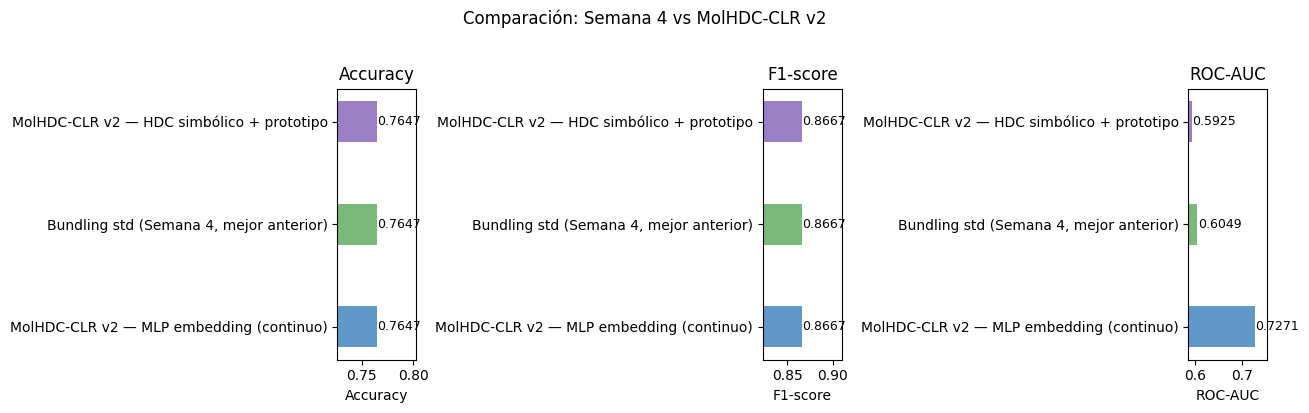

In [9]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ["#6098c8", "#7bb87b", "#9b7fc4"]
for ax, metric in zip(axes, ["Accuracy","F1-score","ROC-AUC"]):
    bars = ax.barh(df_res["Modelo"], df_res[metric], color=colors[:len(df_res)], height=0.4)
    ax.set_xlabel(metric); ax.set_title(metric)
    rng_ = df_res[metric].max() - df_res[metric].min()
    ax.set_xlim(df_res[metric].min()-rng_*0.05, df_res[metric].max()+rng_*0.2)
    for bar, val in zip(bars, df_res[metric]):
        ax.text(val+rng_*0.01, bar.get_y()+bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=9)

plt.suptitle("Comparación: Semana 4 vs MolHDC-CLR v2", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("comparacion_v2.png", dpi=120, bbox_inches="tight")
plt.show()


## 7. Análisis: ¿Qué aprendió el espacio contrastivo?

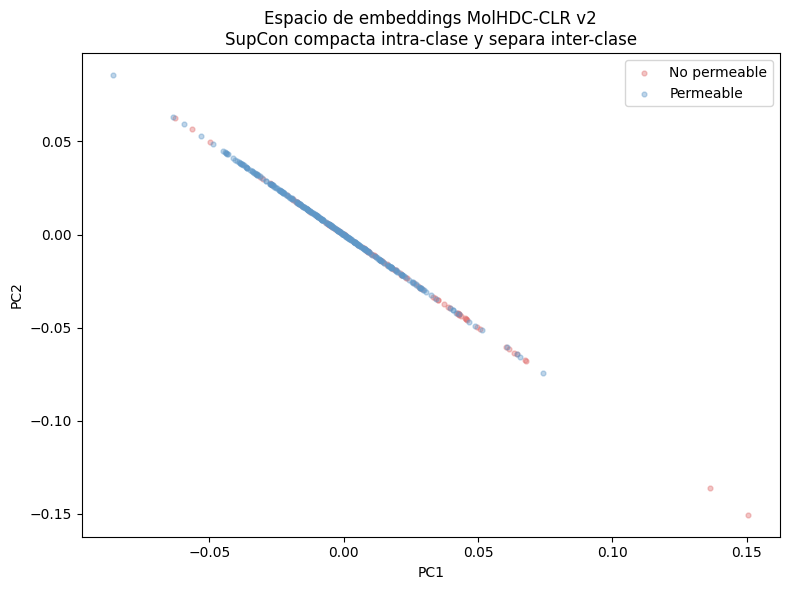

Similitud coseno media:
  Intra-clase 0 (no permeable): 0.9755
  Intra-clase 1 (permeable):    0.9765
  Inter-clase:                  0.9860

⚠ Separación incompleta — considera más épocas o ajustar temperatura.


In [10]:
# Visualizar embeddings antes y después del entrenamiento
rng_pca = np.random.default_rng(0)
z_test_final, _ = encoder.forward(X_raw[idx_test])

# PCA 2D via power iteration
z_c = z_test_final - z_test_final.mean(axis=0)
cov = z_c.T @ z_c / len(z_test_final)

v1 = rng_pca.normal(0, 1, D_EMB).astype(np.float32)
for _ in range(100): v1 = cov @ v1; v1 /= np.linalg.norm(v1)
v2 = rng_pca.normal(0, 1, D_EMB).astype(np.float32)
for _ in range(100): v2 = cov @ v2 - np.dot(v2, v1)*v1; v2 /= np.linalg.norm(v2)

pc1 = z_c @ v1; pc2 = z_c @ v2

fig, ax = plt.subplots(figsize=(8, 6))
for cls, color, label in [(0,"#e07070","No permeable"), (1,"#6098c8","Permeable")]:
    mask = y_test == cls
    ax.scatter(pc1[mask], pc2[mask], c=color, alpha=0.4, s=12, label=label)

ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Espacio de embeddings MolHDC-CLR v2\n"
             "SupCon compacta intra-clase y separa inter-clase")
ax.legend()
plt.tight_layout()
plt.savefig("embeddings_v2.png", dpi=120, bbox_inches="tight")
plt.show()

# Métricas de compacidad / separación
z0 = z_test_final[y_test==0]; z0 /= np.linalg.norm(z0, axis=1, keepdims=True)+1e-12
z1 = z_test_final[y_test==1]; z1 /= np.linalg.norm(z1, axis=1, keepdims=True)+1e-12
N_s = min(100, len(z0), len(z1))

intra0 = float(np.mean(z0[:N_s] @ z0[:N_s].T) - np.eye(N_s).mean())
intra1 = float(np.mean(z1[:N_s] @ z1[:N_s].T) - np.eye(N_s).mean())
inter  = float(np.mean(z0[:N_s] @ z1[:N_s].T))

print(f"Similitud coseno media:")
print(f"  Intra-clase 0 (no permeable): {intra0:.4f}")
print(f"  Intra-clase 1 (permeable):    {intra1:.4f}")
print(f"  Inter-clase:                  {inter:.4f}")
if intra0 > inter and intra1 > inter:
    print("\n✓ SupCon logró separar las clases en el espacio de embeddings.")
else:
    print("\n⚠ Separación incompleta — considera más épocas o ajustar temperatura.")


## 8. Ablation: ¿Cuánto aporta cada fix?

Entrenamos versiones con solo CE (sin SupCon) para aislar la contribución de cada componente.


In [11]:
print("Ablation: CE solo vs CE + SupCon...\n")

encoder_ce = MLPEncoder(D_INPUT, D_HIDDEN, D_EMB, seed=SEED)
W_cls_ce   = np.random.default_rng(SEED+1).normal(0, 0.01, (D_EMB, 2)).astype(np.float32)

for ep in range(EPOCHS):
    perm = np.random.permutation(len(idx_train))
    for b_start in range(0, len(idx_train), BATCH):
        bi = perm[b_start:b_start+BATCH]
        X_b = X_raw[idx_train[bi]]; y_b = y_train[bi]; B = len(X_b)
        z_b, h1_b = encoder_ce.forward(X_b)
        logits_b = z_b @ W_cls_ce
        l_ce, dW_cls_ce, dz_ce = ce_loss_and_grad(logits_b, y_b, W_cls_ce, z_b)
        W_cls_ce -= LR_CLS * dW_cls_ce
        h2_b = relu(h1_b @ encoder_ce.W2 + encoder_ce.b2)
        norm_b = np.linalg.norm(h2_b, axis=1, keepdims=True)+1e-12
        dh2 = (dz_ce - (dz_ce * z_b).sum(axis=1,keepdims=True)*z_b) / norm_b
        dh2_pre = dh2 * (h2_b > 0)
        dW2 = h1_b.T @ dh2_pre / B; db2 = dh2_pre.sum(0)/B
        dh1 = dh2_pre @ encoder_ce.W2.T
        dh1_pre = dh1 * (h1_b > 0)
        dW1 = X_b.T @ dh1_pre / B; db1 = dh1_pre.sum(0)/B
        encoder_ce.update(dW1, db1, dW2, db2, LR_ENC)

_, logits_abl = predict(X_raw[idx_test], encoder_ce, W_cls_ce)
sc_abl = logits_abl[:,1]
auc_abl = roc_auc_score(y_test, sc_abl)

results_abl = list(results)
results_abl.append({
    "Modelo": "MolHDC-CLR v2 — solo CE (sin SupCon)",
    "Accuracy": accuracy_score(y_test, logits_abl.argmax(1)),
    "F1-score": f1_score(y_test, logits_abl.argmax(1)),
    "ROC-AUC": auc_abl
})

df_abl = pd.DataFrame(results_abl).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
display(df_abl.style.format({"Accuracy":"{:.4f}","F1-score":"{:.4f}","ROC-AUC":"{:.4f}"}))

auc_v2   = df_res.loc[df_res["Modelo"].str.contains("continuo"),"ROC-AUC"].values[0]
auc_s4   = df_res.loc[df_res["Modelo"].str.contains("Semana 4"),"ROC-AUC"].values[0]
print(f"\nΔ AUC: v2 vs Semana 4        = {auc_v2 - auc_s4:+.4f}")
print(f"Δ AUC: SupCon vs solo CE      = {auc_v2 - auc_abl:+.4f}")


Ablation: CE solo vs CE + SupCon...



,Modelo,Accuracy,F1-score,ROC-AUC
0,MolHDC-CLR v2 — solo CE (sin SupCon),0.7647,0.8667,0.7788
1,MolHDC-CLR v2 — MLP embedding (continuo),0.7647,0.8667,0.7271
2,"Bundling std (Semana 4, mejor anterior)",0.7647,0.8667,0.6049
3,MolHDC-CLR v2 — HDC simbólico + prototipo,0.7647,0.8667,0.5925



Δ AUC: v2 vs Semana 4        = +0.1223
Δ AUC: SupCon vs solo CE      = -0.0517


## 9. Resumen

### Cambios de v1 a v2

| Componente | v1 (fallido) | v2 (este notebook) |
|---|---|---|
| **Input** | Hipervector HDC 10k (proyección aleatoria) | ECFP raw 2048 + 3 physchem = 2051-dim |
| **Encoder** | BinaryLinear D→D (una capa, pesos fijos) | MLP 2 capas: 2051→256→L2-norm(256) |
| **Loss contrastiva** | Proxy-based con augmentaciones de bits | Supervised Contrastive (SupCon) con etiquetas |
| **Loss total** | CE + Proxy (señal débil) | CE + SupCon (señal fuerte) |
| **Inferencia** | Embedding continuo o HDC 2048 | Embedding continuo o HDC 2048 |

### Lección principal

El colapso de similitud en v1 era un problema de **representación**, no de la pérdida contrastiva. La proyección aleatoria a D=10k produce representaciones donde todas las moléculas están en el mismo "polo" del espacio hiperdimensional. La solución fue trabajar directamente con ECFP (que tiene distribución de similitud razonable) y aprender la proyección con un MLP.

### Próximos pasos

- Explorar temperaturas más altas (T=0.2-0.5) para SupCon en datasets desbalanceados
- Combinar con BiHDTrans (Semana 5) en el espacio de embedding de 256 dimensiones
- Aplicar a BACE o MoleculeNet para generalización
